**Introduction**

The COVID-19 pandemic and the nationwide lockdown in March 2020 significantly disrupted India’s labour market. This project analyzes state-level unemployment data (January–October 2020) to examine how unemployment trends changed during the pandemic period and to identify regional differences in impact.

**Objectives**
- To analyze monthly unemployment trends during 2020.
- To compare unemployment levels before and after the national lockdown.
- To test whether the post-lockdown change in unemployment is statistically significant.
- To evaluate state-wise and regional variations in labour market outcomes.
- To examine the relationship between unemployment rate and labour force participation rate.

## Import Libraries

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
import plotly.express as px
from scipy import stats


## Load Dataset

In [3]:
df = pd.read_csv('data_2020.csv')
df.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
df.shape

(267, 9)

In [5]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

## Rename columns

In [6]:
df.rename(columns={'Region': 'state'}, inplace=True)
df.rename(columns={'Region.1': 'Region'}, inplace=True)

## Check for Missing Values

In [7]:
df.isnull().sum()

state                                       0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region                                      0
longitude                                   0
latitude                                    0
dtype: int64

## Check for Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

## Summary 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   state                                     267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region                                    267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


## Remove Extra Spaces in Columns

In [10]:
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   state                                    267 non-null    object 
 1   Date                                     267 non-null    object 
 2   Frequency                                267 non-null    object 
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region                                   267 non-null    object 
 7   longitude                                267 non-null    float64
 8   latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


## Convert Data Type of "Date" Column

In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df.dtypes

state                                              object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region                                             object
longitude                                         float64
latitude                                          float64
dtype: object

## Summary Statistics

In [12]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [13]:
cat_col = df.select_dtypes(include='object')
cat_col.describe()

,state,Frequency,Region
count,267,267,267
unique,27,1,5
top,Andhra Pradesh,M,North
freq,10,267,79


- The average estimated unemployment rate is elevated. This increase is likely due to the economic disruptions triggered by the pandemic, including lockdown measures, decreased economic activity, and widespread job losses across multiple sectors.

## Drop Unnecessary Column

In [14]:
df = df.drop('Frequency', axis=1)
df.head(5)

,state,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region,longitude,latitude
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,17.43,12988845,36.46,South,15.9129,79.74


## Distribution of Estimated Unemployment Rate

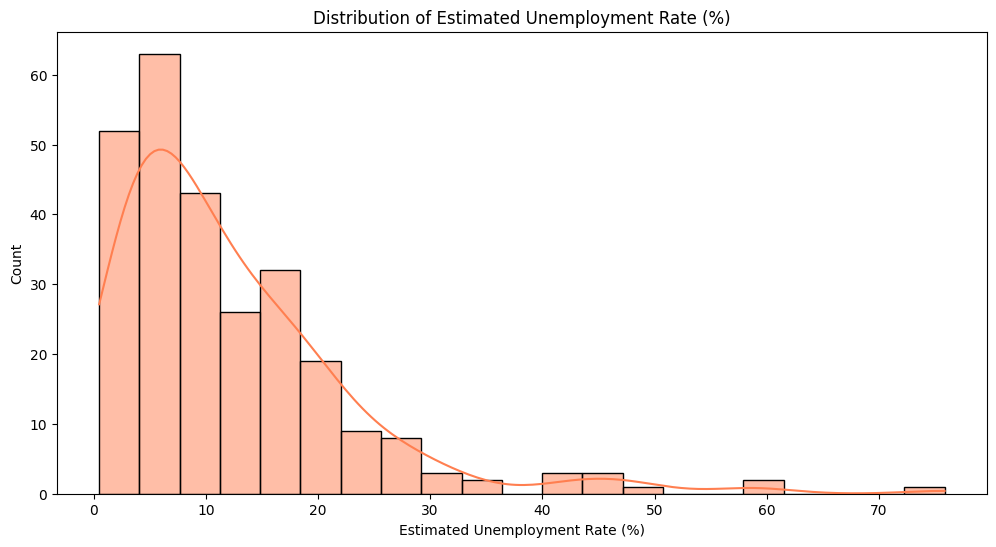

In [17]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True, color='coral')
plt.title('Distribution of Estimated Unemployment Rate (%)')
plt.show()

## Distribution of Estimated Labour Participation Rate

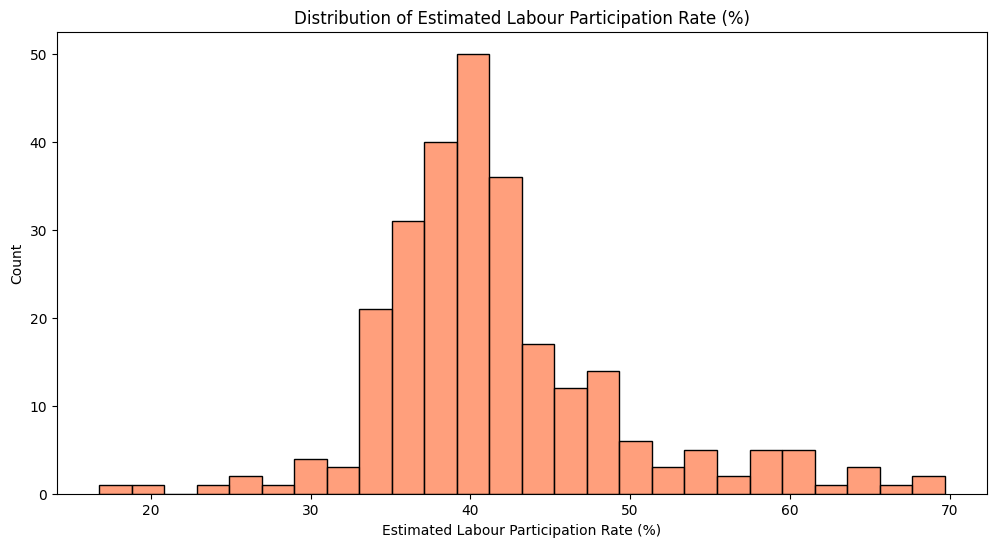

In [30]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df,x="Estimated Labour Participation Rate (%)", color='coral')
plt.title('Distribution of Estimated Labour Participation Rate (%)')
plt.show()

## Distribution of Estimated Estimated Employed

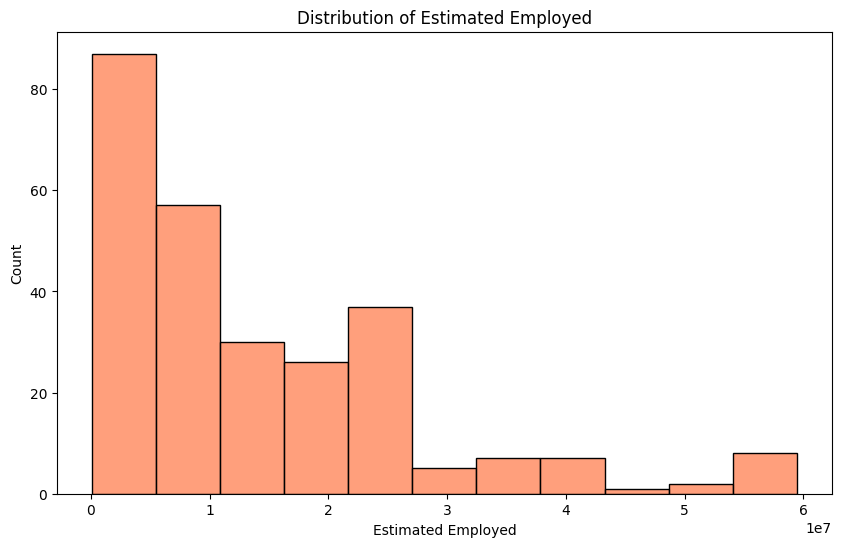

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df,x="Estimated Employed", color='coral')
plt.title('Distribution of Estimated Employed')
plt.show()

## Unemployment Rate vs Labour Participation Rate

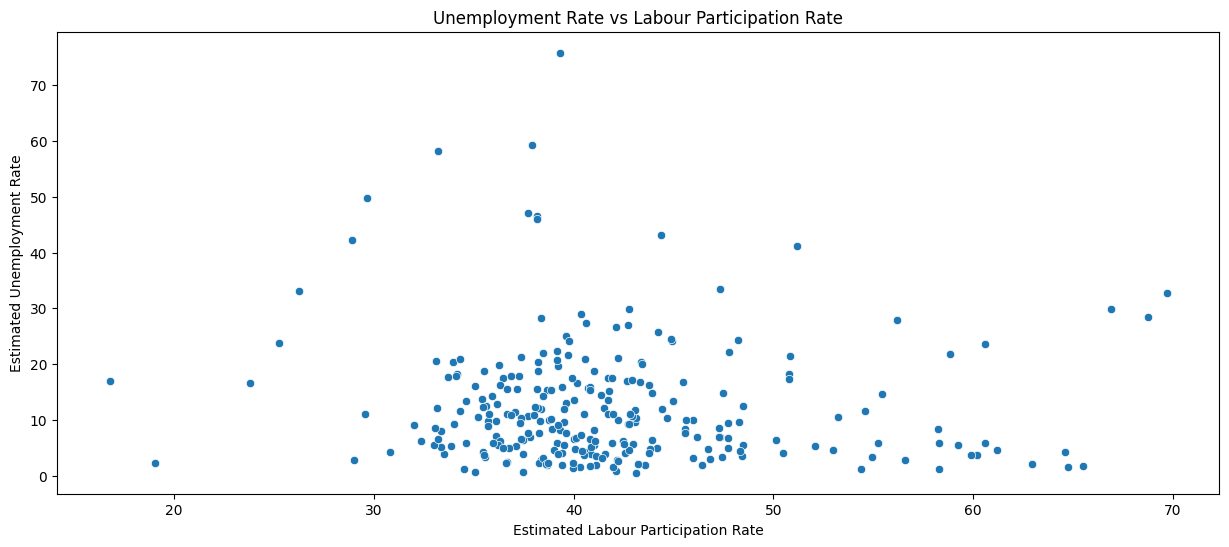

In [31]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='Estimated Labour Participation Rate (%)', y='Estimated Unemployment Rate (%)',
                data=df)
plt.title('Unemployment Rate vs Labour Participation Rate')
plt.xlabel('Estimated Labour Participation Rate')
plt.ylabel('Estimated Unemployment Rate')
plt.show()

- The scatter diagram reveals a broad spread of observations between unemployment rate and labour force participation rate, though certain patterns are evident.
- States with higher labour force participation (above 50%) generally exhibit relatively lower unemployment levels.
- In contrast, states with lower participation rates (below 40%) display substantial variability in unemployment, ranging from minimal levels to extremely high percentages.

Overall, the visualization helps explore the association between labour market engagement and unemployment, providing insight into possible structural trends and economic dynamics across states.

## Outlier Detection

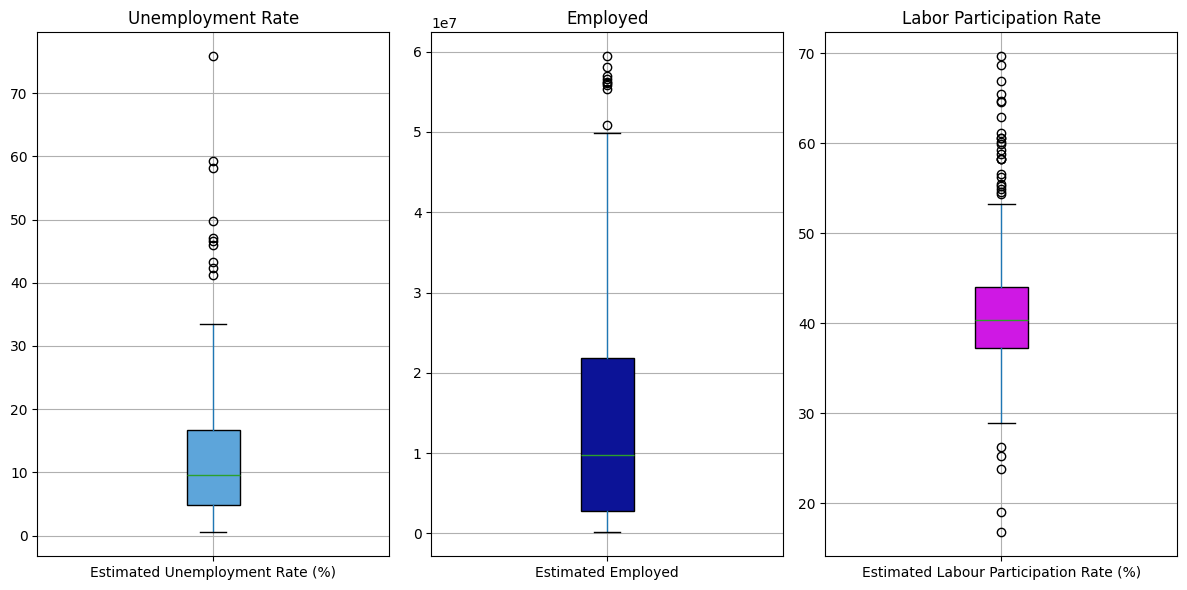

In [89]:
colors = ['#5DA5DA', "#0C1397", "#CF18E4"] 
# Create figure and axes
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
# Subplot 1: Unemployment Rate
df.boxplot(column='Estimated Unemployment Rate (%)',
           ax=ax[0],
           patch_artist=True,
           boxprops=dict(facecolor=colors[0]))
ax[0].set_title('Unemployment Rate')
# Subplot 2: Employed
df.boxplot(column='Estimated Employed',
           ax=ax[1],
           patch_artist=True,
           boxprops=dict(facecolor=colors[1]))
ax[1].set_title('Employed')
# Subplot 3: Labor Participation Rate
df.boxplot(column='Estimated Labour Participation Rate (%)',
           ax=ax[2],
           patch_artist=True,
           boxprops=dict(facecolor=colors[2]))
ax[2].set_title('Labor Participation Rate')
plt.tight_layout()
plt.show()

- Outliers were identified in the dataset. However, since this study examines unemployment trends during the COVID-19 period, these extreme values likely represent actual economic disruptions caused by the pandemic. As a result, the outliers were retained to ensure the analysis accurately reflects the real-world impact of this period.

## Distribution of Unemployment Rates Across Different States.

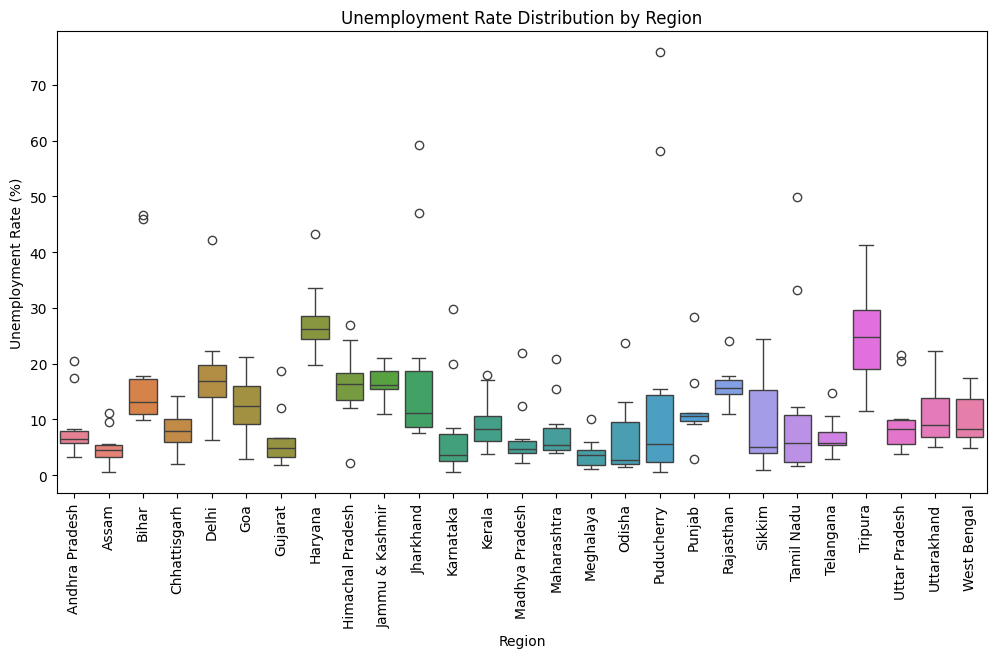

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='state', y='Estimated Unemployment Rate (%)', data=df, hue='state')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.title('Unemployment Rate Distribution by Region')
plt.xticks(rotation=90)
plt.show()

The distributional analysis highlights clear disparities in unemployment levels across states during the study period.
- Geographical trends: Northern and Western states generally report higher unemployment levels relative to Southern states. Eastern states such as Bihar and Assam reflect moderate levels accompanied by substantial dispersion.
- Extreme observations: Goa, Jammu & Kashmir, and Telangana display pronounced spikes, suggesting temporary but substantial labour market disruptions.
- States with elevated unemployment levels: Haryana, Himachal Pradesh, and Delhi exhibit comparatively higher central tendencies along with noticeable fluctuations over time.
- States with relatively stable labour markets: Andhra Pradesh, Gujarat, Maharashtra, and Uttar Pradesh demonstrate lower central values and narrower distributions, indicating greater stability.


Overall pattern: The impact of the COVID-19 period was uneven across regions, with significant cross-state variation in both intensity and volatility of unemployment rates. These findings emphasize the heterogeneous nature of labour market responses during the pandemic period.

## Pearson Correlation 

In [90]:
cnf_mat = df.select_dtypes(include='number')
cnf_mat.corr()['Estimated Unemployment Rate (%)']


Estimated Unemployment Rate (%)            1.000000
Estimated Employed                        -0.245176
Estimated Labour Participation Rate (%)   -0.073540
longitude                                  0.149976
latitude                                  -0.023976
Name: Estimated Unemployment Rate (%), dtype: float64

## Correlation Heatmap

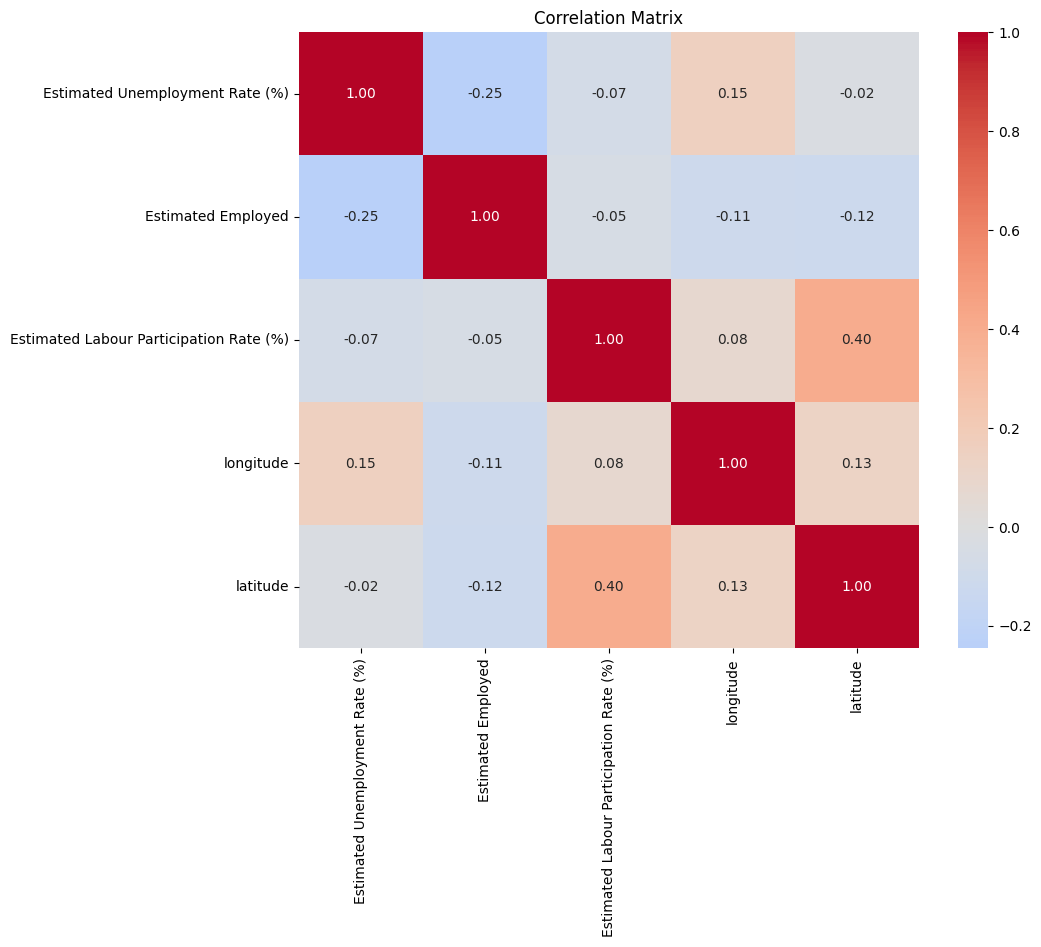

In [91]:
corr_matrix = cnf_mat.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",center=0)
plt.title("Correlation Matrix")
plt.show()

- No significant positive or negative correlations are observed between the variables.

## Pair PLot of Numerical Variables 

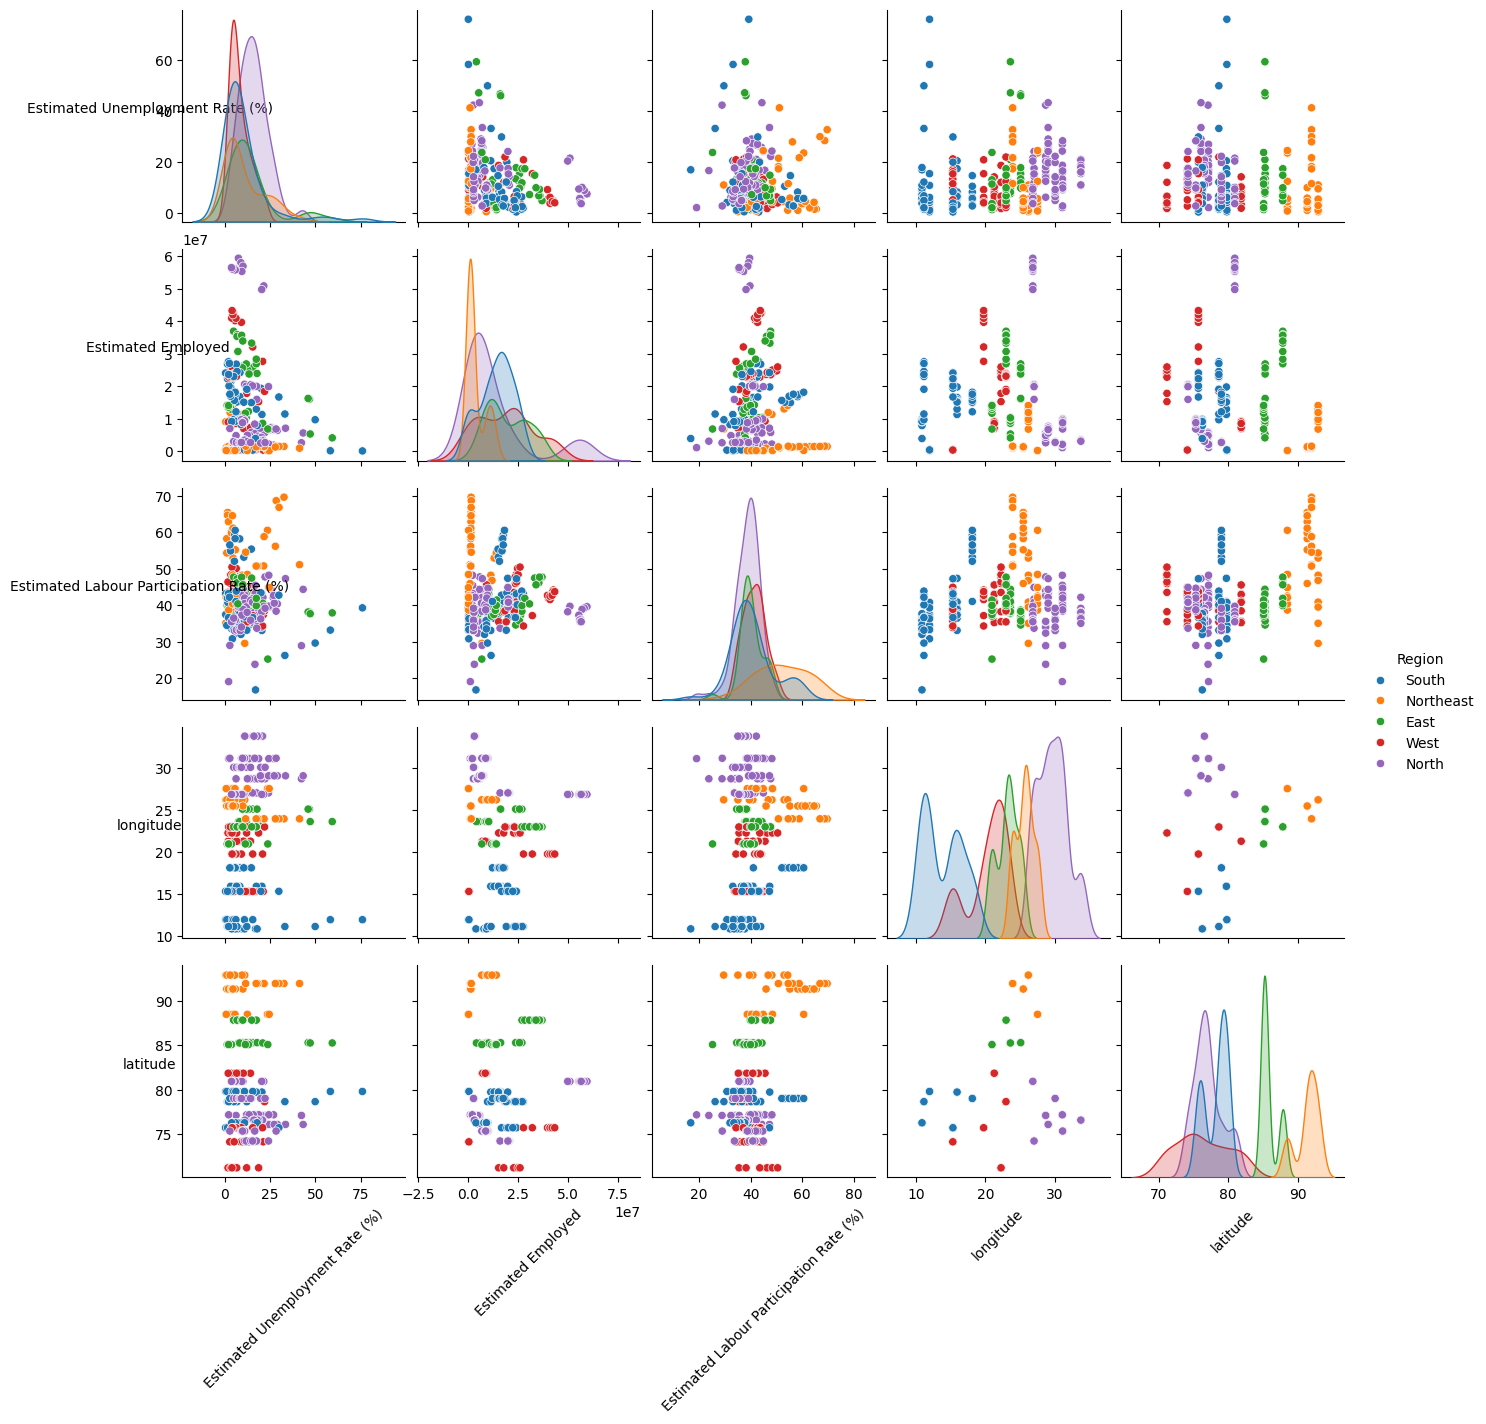

In [92]:
g = sns.pairplot(df, hue='Region')
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=45)
        ax.set_ylabel(ax.get_ylabel(), rotation=0)
plt.show()

## Unemployment Rate Over Time

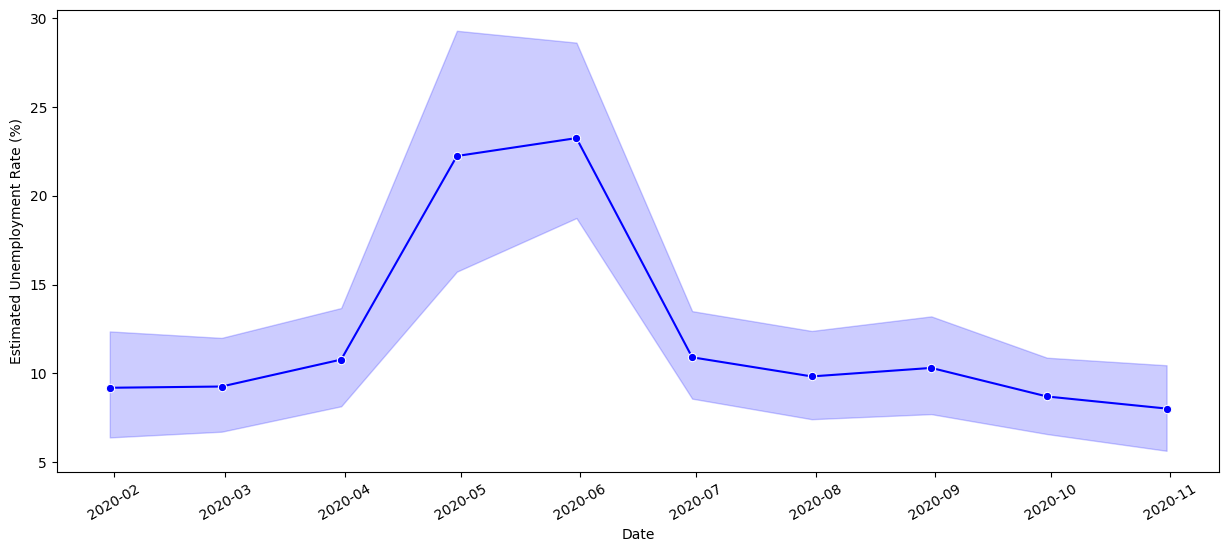

In [93]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', marker='o',color='blue')
plt.xticks(rotation=30)

plt.show()

- Higher unemployment rates were observed during April, May, and June, which can be attributed to lockdown restrictions that disrupted economic operations and led to widespread job losses.  

##### Unemployment rate in each state

In [94]:
unemp_state = df[['Estimated Unemployment Rate (%)','state']]
unemp = unemp_state.groupby('state').mean().reset_index()
unemp = unemp.sort_values(by = 'Estimated Unemployment Rate (%)', ascending=False)
fig = px.bar(unemp, x='state',y='Estimated Unemployment Rate (%)',color = 'state',
             title = 'Average Unemployment Rate in States')
fig.show()

- Haryana has the highest estimated unemployment rate followed by Tripura.  

## Unemployment Rates in Different Region

In [95]:
fig = px.violin(df, x='Region', y='Estimated Unemployment Rate (%)',
    title='Region wise distribution of Unemployment Rates ',
    box=True,points='all', color='Region')
fig.show()

- The broader and taller violin distributions suggest greater variation in unemployment rates, indicating that southern and eastern India faced relatively higher unemployment levels.

## Labour Participation Rates by state Over Time

In [96]:
# labour_rate = df.groupby(['Date', 'state'])['Estimated Labour Participation Rate (%)'].mean().reset_index()
# labour_rate
fig = px.area(df,x='Date',y='Estimated Labour Participation Rate (%)',color='state')
fig.update_layout(xaxis_title='Date',yaxis_title='Labour Participation Rate (%)',
    legend_title='state')
fig.show()

## Before / After Lockdown Comparison

In [97]:
lockdown_date = pd.to_datetime('2020-03-25')
before = df[df['Date'] < lockdown_date].copy()
after  = df[df['Date'] >= lockdown_date].copy()

# compute per-state mean unemployment before & after (align states)
bef = before.groupby('state')['Estimated Unemployment Rate (%)'].mean().rename('before').reset_index()
aft = after.groupby('state')['Estimated Unemployment Rate (%)'].mean().rename('after').reset_index()

changes = pd.merge(bef, aft, on='state', how='outer')
changes['before'] = changes['before'].fillna(0)
changes['after'] = changes['after'].fillna(0)

# relative change: handle divide-by-zero carefully
def pct_change(before, after):
    if before == 0:
        return np.nan if after == 0 else np.inf
    return (after - before) / before

changes['relative_change'] = changes.apply(lambda r: pct_change(r['before'], r['after']), axis=1)
changes['absolute_change'] = changes['after'] - changes['before']

# sort
changes = changes.sort_values('relative_change', ascending=False)
changes.head(20)

,state,before,after,relative_change,absolute_change
20,Sikkim,0.000,9.79250,inf,9.79250
17,Puducherry,1.170,22.13500,17.918803,20.96500
21,Tamil Nadu,1.830,14.77625,7.074454,12.94625
16,Odisha,2.510,7.45000,1.968127,4.94000
11,Karnataka,3.235,8.77625,1.712906,5.54125
25,Uttarakhand,5.240,12.63500,1.411260,7.39500
5,Goa,5.850,13.74625,1.349786,7.89625
2,Bihar,10.450,21.72625,1.079067,11.27625
10,Jharkhand,11.230,21.61625,0.924866,10.38625
26,West Bengal,5.930,11.25750,0.898398,5.32750


## Statistical Tests (paired across states)

In [98]:
# remove states where either before or after is nan / inf
test_df = changes.replace([np.inf, -np.inf], np.nan).dropna(subset=['before','after'])

# paired t-test (assumes distribution approx normal)
tstat, pval = stats.ttest_rel(test_df['after'], test_df['before'])
print("paired t-stat:", tstat, "p-value:", pval)

# non-parametric alternative: Wilcoxon signed-rank
wstat, wp = stats.wilcoxon(test_df['after'], test_df['before'])
print("wilcoxon:", wstat, "p:", wp)

paired t-stat: 3.659176523227995 p-value: 0.001129641851188286
wilcoxon: 54.0 p: 0.000667765736579895


- The paired t-test (t = 3.659, p = 0.00113) indicates a statistically significant difference between the after-lockdown and before-lockdown unemployment rates across states. Because the t-statistic is positive, the mean unemployment after the lockdown is higher than before.
- The Wilcoxon signed-rank test (W = 54.0, p = 0.00067), a nonparametric alternative, also finds a statistically significant change in the same direction.\
Conclusion: There is strong evidence that unemployment levels changed after the lockdown; specifically, they increased on average.

## Change in Unemployment Rate After Lockdown

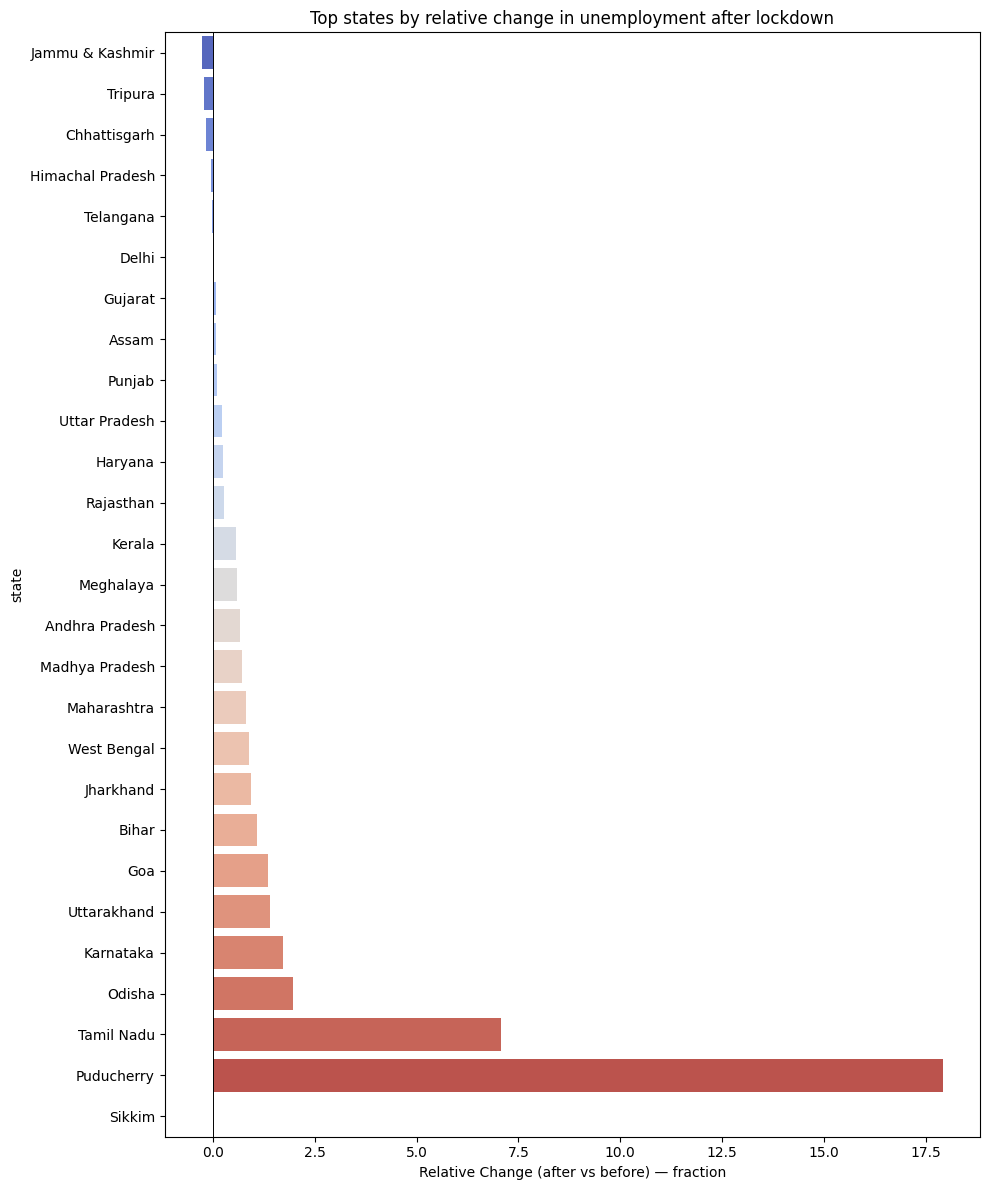

In [99]:
plt.figure(figsize=(10,12))
sns.barplot(data=changes.sort_values('relative_change', ascending=True).head(30),
            x='relative_change', y='state', palette='coolwarm')
plt.xlabel('Relative Change (after vs before) — fraction')
plt.title('Top states by relative change in unemployment after lockdown')
plt.axvline(0, color='k', linewidth=0.7)
plt.tight_layout()
plt.show()

## Average Estimated Unemployment Rate Over Time

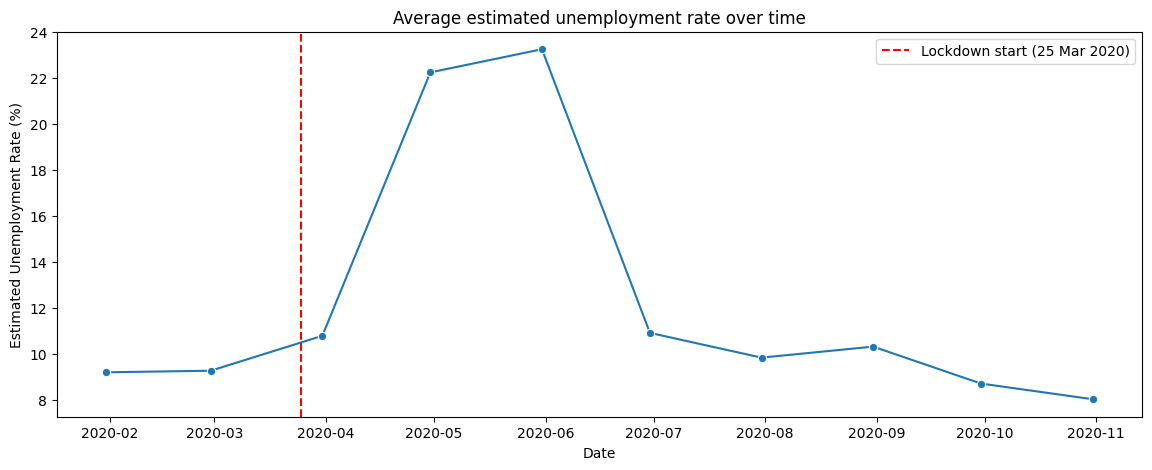

In [100]:
date_unemp = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
plt.figure(figsize=(14,5))
sns.lineplot(data=date_unemp, x='Date', y='Estimated Unemployment Rate (%)', marker='o')
plt.axvline(lockdown_date, color='red', linestyle='--', label='Lockdown start (25 Mar 2020)')
plt.title('Average estimated unemployment rate over time')
plt.legend()
plt.show()


## State Wise Unemployment Rate Over Time

In [101]:
ts = df.groupby(['Date','state'])['Estimated Unemployment Rate (%)'].mean().reset_index()
fig= px.line(ts, x='Date', y='Estimated Unemployment Rate (%)', color='state')

fig.show()


# Insights from Unemployment Analysis

- The national unemployment rate shows a sharp spike around April–May 2020, coinciding with the COVID-19 lockdown period.
  
- Statistical tests on state-level averages confirm a significant increase in unemployment after the lockdown: paired t-test (t = 3.659, p = 0.00113) and Wilcoxon signed-rank (W = 54.0, p = 0.00067). This means the average state unemployment after the lockdown was statistically higher than before.
  
- Impact was heterogeneous across states, a few territories experienced extreme spikes while many states showed modest or even decreased unemployment. Notable extreme month values include Puducherry (75.85%), Tamil Nadu (49.83%), Bihar (46.64%) and Maharashtra (20.90%) in Apr 2020.
  
- Tripura, Tilangana, Chattisgarh, Jammu & Kashmir and Himachal Pradesh have negetive percentage change which means these states are not highly impacted by the lock down.
  
- Regional dispersion differs in South and East regions show larger violin spreads in unemployment (higher variability across states), while some Northeast states show high volatility month-to-month.
